<a href="https://colab.research.google.com/github/tejasbawane/Maincrafts_Technology_Internship/blob/main/AI_ML_Task3_Classification_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load and Prepare Dataset

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Separate features and target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
print(f"Dataset loaded. Features shape: {X.shape}, Target shape: {y.shape}\n")

Dataset loaded. Features shape: (20640, 8), Target shape: (20640,)



In [3]:
# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling complete.\n")

Feature scaling complete.



In [4]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}\n")

Training set size: 16512, Testing set size: 4128



In [5]:
import numpy as np
# Detect Overfitting (Unconstrained Decision Tree)

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

# Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Interpretation: The massive gap (~{test_rmse - train_rmse:.4f}) indicates severe overfitting.\n")

Training RMSE: 0.0000
Testing RMSE: 0.7030
Interpretation: The massive gap (~0.7030) indicates severe overfitting.



In [6]:
# Cross-Validation

cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
# Convert negative RMSE back to positive
cv_rmse = -cv_scores.mean()
print(f"5-Fold Cross-Validation Mean RMSE: {cv_rmse:.4f}\n")

5-Fold Cross-Validation Mean RMSE: 0.8957



In [7]:
# Hyperparameter Tuning Using GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
grid.fit(X_train, y_train)

print(f"Best Parameters Found: {grid.best_params_}\n")

Best Parameters Found: {'max_depth': 10, 'min_samples_split': 10}



In [8]:
# Evaluate Optimized Model

import numpy as np
best_tree = grid.best_estimator_
y_pred_tree = best_tree.predict(X_test)

tuned_tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tuned_tree_r2 = r2_score(y_test, y_pred_tree)

print(f"Tuned Tree Test RMSE: {tuned_tree_rmse:.4f}")
print(f"Tuned Tree Test R² Score: {tuned_tree_r2:.4f}\n")

Tuned Tree Test RMSE: 0.6454
Tuned Tree Test R² Score: 0.6821



In [9]:
import numpy as np
# Train Baseline Models & Build Model Comparison Summary Table
# Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

# Baseline Ridge Regression
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

# Summary DataFrame
results = {
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, tuned_tree_rmse],
    "R2 Score": [lr_r2, ridge_r2, tuned_tree_r2]
}

df_results = pd.DataFrame(results)
display(df_results)
print("\n")

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


--- Generating Optional Task Visualizations ---


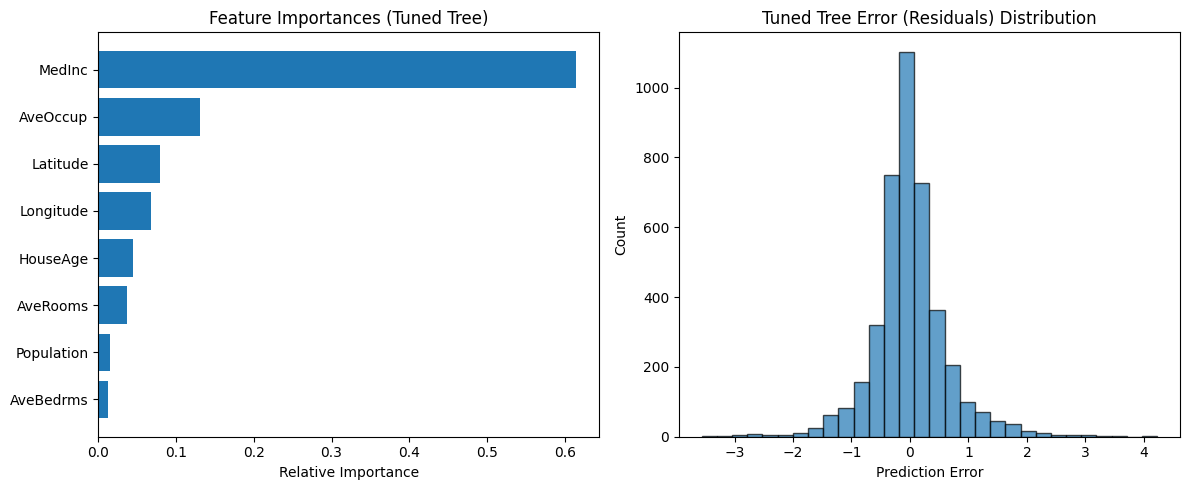

In [10]:
# Feature Importance & Error Distribution
print("--- Generating Optional Task Visualizations ---")
plt.figure(figsize=(12, 5))

# Plot 1: Feature Importances for Tuned Decision Tree
plt.subplot(1, 2, 1)
importances = best_tree.feature_importances_
indices = np.argsort(importances)
plt.title("Feature Importances (Tuned Tree)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.xlabel("Relative Importance")

# Plot 2: Residual Analysis
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_tree
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title("Tuned Tree Error (Residuals) Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Count")

plt.tight_layout()
plt.show()